# **CHAPTER 8: Dimensionality Reduction**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import cv2
# Each row is a point (x1, x2, x3)
X = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5],
    [5, 6, 7],
    [6, 7, 8],
    [7, 8, 9],
    [1, 0, 2],
    [2, 1, 3],
    [3, 1, 4],
    [4, 2, 5]
])


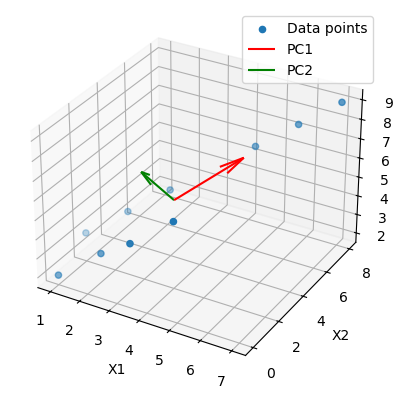

In [30]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

c1 = Vt[0]   # first principal direction
c2 = Vt[1]   # second principal direction

origin = X.mean(axis=0)

# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# data points
ax.scatter(X[:,0], X[:,1], X[:,2], label="Data points")

# principal directions (scaled for visibility)
ax.quiver(*origin, *(c1 * 3), color='r', label='PC1')
ax.quiver(*origin, *(c2 * 3), color='g', label='PC2')

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

plt.legend()
plt.show()

PCA on 3 feature

In [31]:
df = pd.read_csv(r'/home/noneo/Codes/ML/MachineLearning/Datasets/purchase.csv')
df 

,Person,Ball,Bat,apple,Orange,Price
0,A,3.0,2.0,20.0,20.0,NaN
1,B,2.0,NaN,30.0,40.0,NaN
2,C,NaN,3.0,50.0,70.0,123.0
3,D,4.0,3.0,10.0,100.0,NaN
4,E,NaN,6.0,80.0,150.0,NaN
5,F,2.0,NaN,90.0,NaN,456.0
6,G,2.0,7.0,100.0,NaN,890.0
7,H,NaN,2.0,70.0,NaN,145.0
8,I,6.0,NaN,NaN,NaN,776.0
9,J,1.0,NaN,NaN,NaN,998.0


In [32]:
df['Ball'] = df['Ball'].fillna(df['Ball'].median())
df['apple'] = df['apple'].fillna(df["apple"].mean())
df['Orange'] = df['Orange'].fillna(df["Orange"].mean())
df['Price'] = df['Price'].fillna(df["Price"].median())
df['Bat'] = df['Bat'].fillna(df['Bat'].mean())
df

,Person,Ball,Bat,apple,Orange,Price
0,A,3.0,2.000000,20.00,20.0,616.0
1,B,2.0,3.833333,30.00,40.0,616.0
2,C,2.0,3.000000,50.00,70.0,123.0
3,D,4.0,3.000000,10.00,100.0,616.0
4,E,2.0,6.000000,80.00,150.0,616.0
5,F,2.0,3.833333,90.00,76.0,456.0
6,G,2.0,7.000000,100.00,76.0,890.0
7,H,2.0,2.000000,70.00,76.0,145.0
8,I,6.0,3.833333,56.25,76.0,776.0
9,J,1.0,3.833333,56.25,76.0,998.0


In [33]:
df = df.drop(['Person', 'apple'], axis=1)

In [34]:
import plotly.express as px
fig = px.scatter_3d(df, x='Ball', y='Bat', z='Orange',
                    color=df['Price'].astype(str)) # Keeps color discrete
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target (Make sure df is your original DataFrame here!)
X = df.drop('Price', axis=1)
y = df['Price']

# 2. Scale the features (Assign to a NEW variable name so you don't overwrite X or df!)
ss = StandardScaler()
X_scaled = ss.fit_transform(X)

# 3. Calculate Covariance Matrix 
covariance_matrix = np.cov(X_scaled.T)

print("Covariance Matrix:\n", covariance_matrix)

Covariance Matrix:
 [[ 1.11111111 -0.18972823 -0.02020369]
 [-0.18972823  1.11111111  0.5622334 ]
 [-0.02020369  0.5622334   1.11111111]]


In [36]:

# Step 3 - Finding EV (Eigenvalues) and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print("Eigenvalues:\n", eigen_values)
print("\nEigenvectors:\n", eigen_vectors)

Eigenvalues:
 [1.71085961 1.09887846 0.52359526]

Eigenvectors:
 [[ 0.24494016 -0.94733581 -0.20629875]
 [-0.70320164 -0.02709964 -0.71047383]
 [-0.66746668 -0.31909319  0.67280589]]


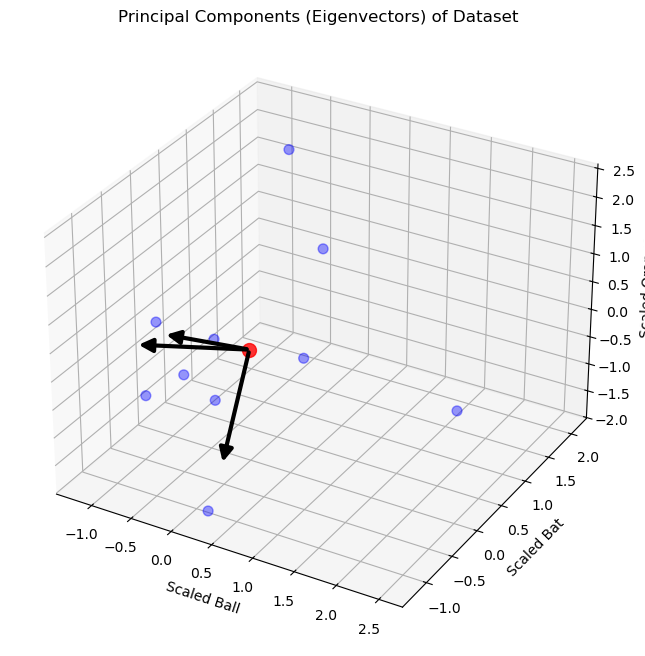

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# 1. Define updated custom 3D Arrow class compatible with modern Matplotlib
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# 2. Initialize 3D Plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot scaled data points (Column 0: Ball, Column 1: Bat, Column 2: Orange)
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], color='blue', alpha=0.4, s=50)

# 4. Find the center/mean of the scaled dataset (Should be at [0,0,0])
mean_x = X_scaled[:, 0].mean()
mean_y = X_scaled[:, 1].mean()
mean_z = X_scaled[:, 2].mean()
ax.scatter([mean_x], [mean_y], [mean_z], color='red', alpha=0.8, s=100)

# 5. Plot the Eigenvectors pointing out from the dataset center
for v in eigen_vectors.T:
    # Scale up the vector slightly (multiplied by 1.5) so it stands out visually
    a = Arrow3D([mean_x, mean_x + v[0] * 1.5], 
                [mean_y, mean_y + v[1] * 1.5], 
                [mean_z, mean_z + v[2] * 1.5], 
                mutation_scale=20, lw=3, arrowstyle="-|>", color="black")
    ax.add_artist(a)

# 6. Set labels using your actual feature names
ax.set_xlabel('Scaled Ball')
ax.set_ylabel('Scaled Bat')
ax.set_zlabel('Scaled Orange')
plt.title('Principal Components (Eigenvectors) of Dataset')

plt.show()

In [38]:

# 1. Select the top 2 principal components (eigenvectors)
# Since np.linalg.eig returns them as columns, we take the first two columns
pc = eigen_vectors[:, 0:2]

# 2. Transform the scaled dataset by multiplying it with the principal components
# X_scaled is shape (N, 3) and pc is shape (3, 2) -> result is shape (N, 2)
transformed_data = np.dot(X_scaled, pc)

# 3. Create a new DataFrame for the 2D data
new_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2'])

# 4. Bring back your original target column ('Price') to match the new rows
new_df['Price'] = y.values

# Look at the final, dimensionality-reduced dataset
print(new_df.head())

        PC1       PC2  Price
0  2.077818  0.304457  616.0
1  0.632496  0.773201  616.0
2  0.402935  0.493005  123.0
3  0.146714 -1.198908  616.0
4 -2.639475 -0.347843  616.0


In [39]:
import plotly.express as px

# 1. Keep 'Price' numerical (Do NOT convert it to a string)
new_df['Price'] = new_df['Price'].astype(float)

# 2. Build the plot using continuous color scaling
fig = px.scatter(
    new_df,               # Pass the dataframe first
    x='PC1',              # Use column names directly as strings
    y='PC2',
    color='Price',        # Plotly automatically applies a continuous color scale
    color_continuous_scale=px.colors.sequential.Viridis, # Clean gradient scale
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'}
)

# 3. Update marker styles
fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1.5, color='DarkSlateGrey')
    ),
    selector=dict(mode='markers')
)

fig.show()

In [40]:
# **Singular Value Decomposition**

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve
from deslib.des.knora_e import KNORAE


from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


In [ ]:
X, y = fetch_openml('mnist_784', version=1,
                    return_X_y=True, as_frame=False,
                    parser='pandas'
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train_scaled)
X_test_trf = pca.transform(X_test_scaled)
X_val_trf = pca.transform(X_val_scaled)

In [ ]:
X_train_trf

array([[10.34823457,  1.04491162, -1.4209505 ],
       [ 4.00015324,  9.2259736 ,  0.97047627],
       [-2.77861991,  6.99467795, -2.19512664],
       ...,
       [-2.96274694, -4.75094986, -4.17449725],
       [ 1.76506455,  0.21121063,  6.46838361],
       [-5.0916657 , -4.17720607,  2.63392943]])

In [ ]:
y_train_trf = y_train.astype(str)

y_train_trf

array(['0', '5', '4', ..., '5', '2', '6'], dtype='<U1')

In [ ]:
import plotly.io as pio
pio.renderers.default = "browser"

# Your plotting code here...
fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:,  1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10,
    # render_mode='svg'
)
fig.show()

In [ ]:

fig = px.scatter_3d(
    x=X_train_trf[:, 0], 
    y=X_train_trf[:, 1], 
    z=X_train_trf[:, 2],
    color=y_train_trf
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)

fig.show()

# **Unsupervised Learning Techniques**


## **Clustering Algorithms: k-means and DBSCAN**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris, make_blobs
from sklearn.datasets import make_blobs
from pandas.plotting import scatter_matrix


In [2]:
X, y = load_iris(return_X_y=True,as_frame=True)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


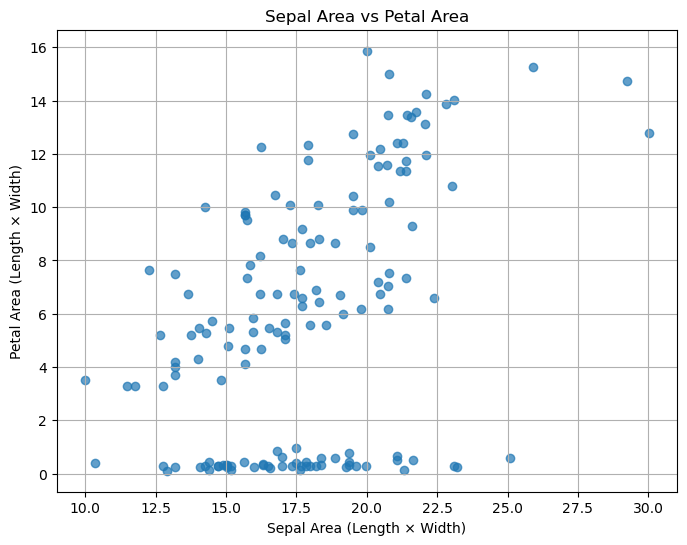

In [3]:

X['Sepal_Area'] = X['sepal length (cm)'] * X['sepal width (cm)']
X['Petal_Area'] = X['petal length (cm)'] * X['petal width (cm)']

plt.figure(figsize=(8,6))

plt.scatter(X['Sepal_Area'], X['Petal_Area'], alpha=0.7)

plt.xlabel("Sepal Area (Length × Width)")
plt.ylabel("Petal Area (Length × Width)")
plt.title("Sepal Area vs Petal Area")

plt.grid(True)
plt.show()

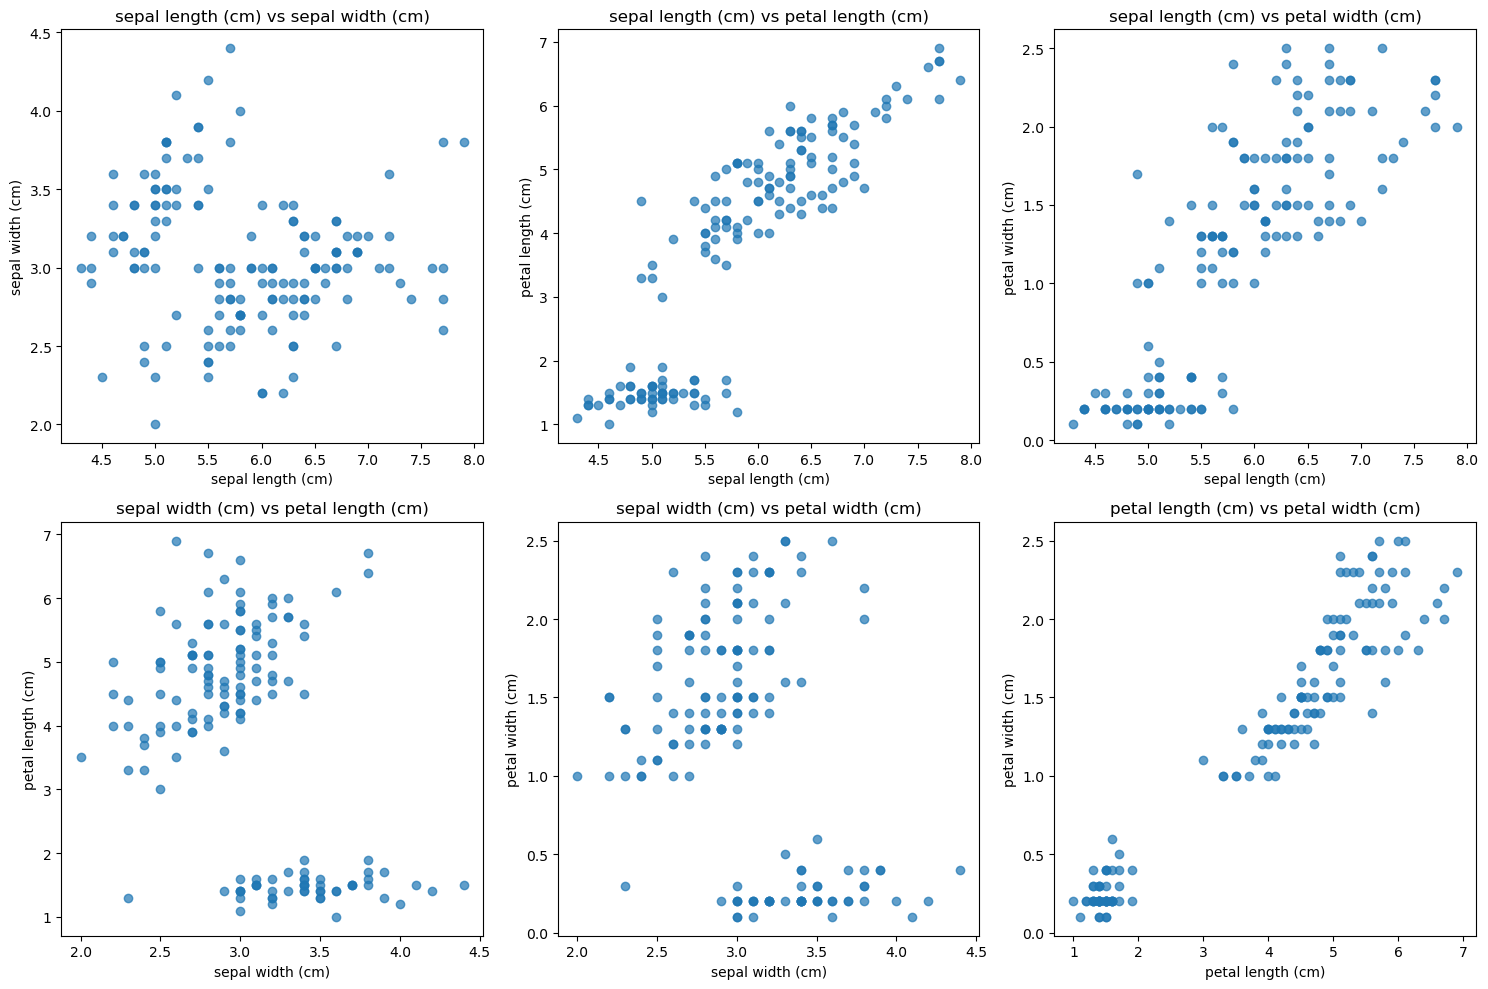

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

pairs = [
    ('sepal length (cm)', 'sepal width (cm)'),
    ('sepal length (cm)', 'petal length (cm)'),
    ('sepal length (cm)', 'petal width (cm)'),
    ('sepal width (cm)', 'petal length (cm)'),
    ('sepal width (cm)', 'petal width (cm)'),
    ('petal length (cm)', 'petal width (cm)')
]

for ax, (x_col, y_col) in zip(axes.ravel(), pairs):
    ax.scatter(X[x_col], X[y_col], alpha=0.7)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')

plt.tight_layout()
plt.show()

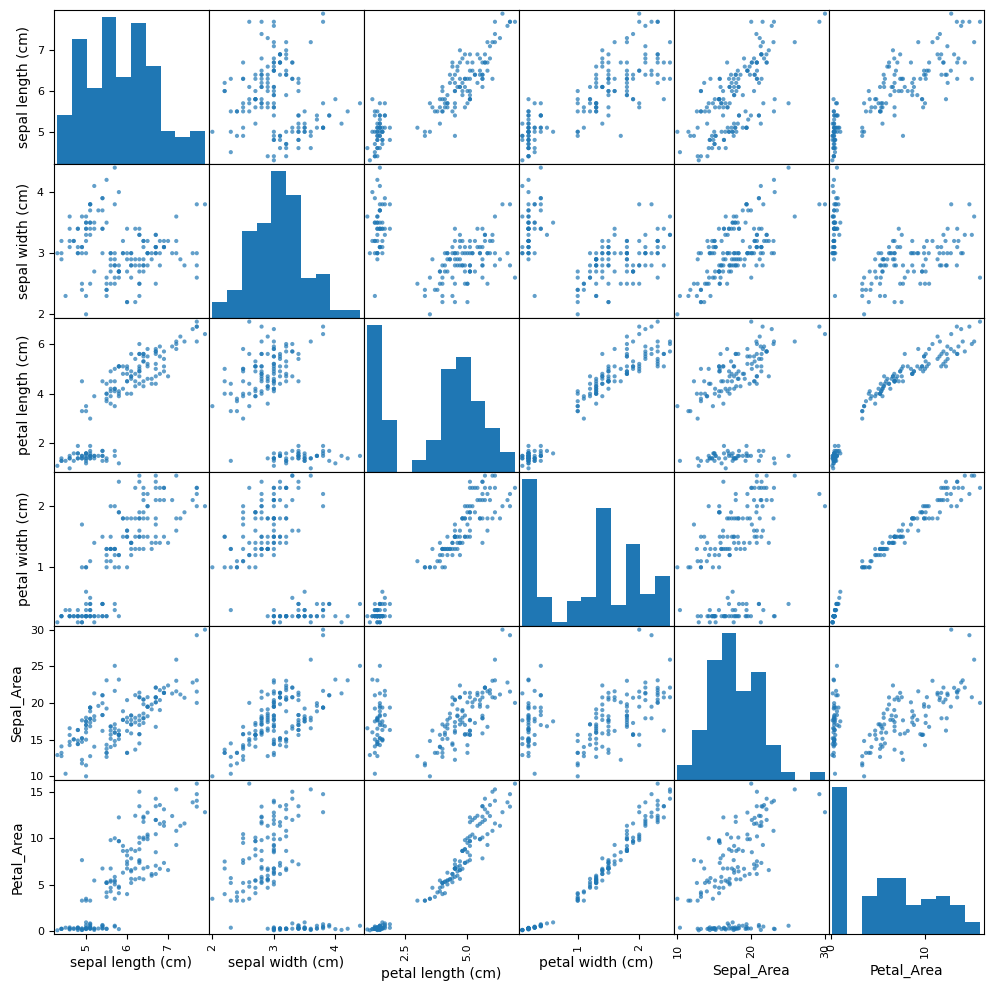

In [5]:

scatter_matrix(
    X,
    figsize=(12, 12),
    diagonal='hist',
    alpha=0.7
)

plt.show()

In [6]:
y.unique()

array([0, 1, 2])

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)

y_pred = kmeans.fit_predict(X)

print(y_pred)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0
 0 1]


Predicted_Cluster   0   1   2
True_Label                   
0                   0   0  50
1                   7  43   0
2                  36  14   0


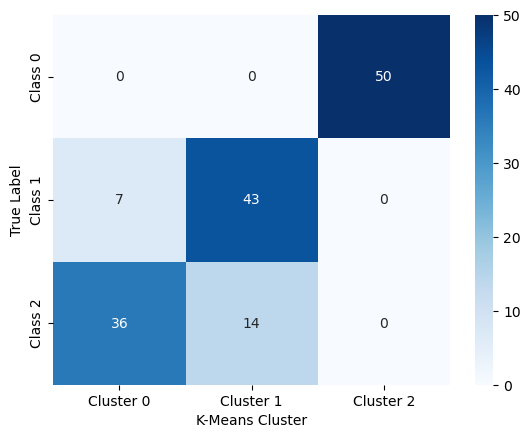

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

df_compare = pd.DataFrame({'True_Label': y, 'Predicted_Cluster': y_pred})
print(pd.crosstab(df_compare['True_Label'], df_compare['Predicted_Cluster']))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('K-Means Cluster')
plt.ylabel('True Label')
plt.show()

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data
X, y = make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=1.0,
    random_state=42
)

# Train K-Means
kmeans = KMeans(n_clusters=5, random_state=42)

# Predict clusters
y_pred = kmeans.fit_predict(X)

print(y_pred)

[3 0 3 0 3 4 0 2 1 0 0 3 0 3 0 3 0 0 0 3 3 0 3 0 0 3 2 0 0 2 1 0 0 1 2 0 0
 0 4 0 3 0 2 1 0 1 3 2 0 2 4 0 2 1 3 1 0 3 4 2 3 4 0 0 2 0 2 2 2 2 0 2 4 0
 4 3 4 1 0 3 2 3 3 0 3 2 4 0 0 0 0 0 3 0 3 3 0 1 0 0 4 4 0 2 3 3 3 0 3 0 4
 0 0 0 3 3 3 2 4 1 4 2 1 1 3 2 0 0 4 3 0 1 0 3 3 3 3 0 2 0 3 4 3 0 0 3 0 2
 0 2 0 2 2 0 3 0 2 4 3 0 1 1 0 0 3 1 0 0 0 0 2 3 0 0 3 0 4 0 2 2 4 1 0 2 2
 0 3 1 2 0 0 2 3 2 2 1 4 2 0 0 1 2 0 0 1 3 3 2 2 3 2 1 0 2 3 0 1 1 2 0 1 4
 0 4 0 0 1 0 4 0 1 0 0 2 0 0 0 0 0 3 4 0 2 0 2 1 0 0 2 2 0 0 4 2 4 0 2 0 2
 0 2 3 0 0 0 3 0 0 2 0 1 2 2 3 3 4 0 0 0 0 1 3 3 0 0 2 2 2 0 0 4 0 2 4 3 4
 2 3 0 3]


In [10]:


# Generate synthetic data
X, y = make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=1.0,
    random_state=42
)

# Train K-Means 
kmeans = KMeans(n_clusters=5,random_state=42)

# Predict clusters
y_pred = kmeans.fit_predict(X)

print(y_pred)

[3 0 3 0 3 4 0 2 1 0 0 3 0 3 0 3 0 0 0 3 3 0 3 0 0 3 2 0 0 2 1 0 0 1 2 0 0
 0 4 0 3 0 2 1 0 1 3 2 0 2 4 0 2 1 3 1 0 3 4 2 3 4 0 0 2 0 2 2 2 2 0 2 4 0
 4 3 4 1 0 3 2 3 3 0 3 2 4 0 0 0 0 0 3 0 3 3 0 1 0 0 4 4 0 2 3 3 3 0 3 0 4
 0 0 0 3 3 3 2 4 1 4 2 1 1 3 2 0 0 4 3 0 1 0 3 3 3 3 0 2 0 3 4 3 0 0 3 0 2
 0 2 0 2 2 0 3 0 2 4 3 0 1 1 0 0 3 1 0 0 0 0 2 3 0 0 3 0 4 0 2 2 4 1 0 2 2
 0 3 1 2 0 0 2 3 2 2 1 4 2 0 0 1 2 0 0 1 3 3 2 2 3 2 1 0 2 3 0 1 1 2 0 1 4
 0 4 0 0 1 0 4 0 1 0 0 2 0 0 0 0 0 3 4 0 2 0 2 1 0 0 2 2 0 0 4 2 4 0 2 0 2
 0 2 3 0 0 0 3 0 0 2 0 1 2 2 3 3 4 0 0 0 0 1 3 3 0 0 2 2 2 0 0 4 0 2 4 3 4
 2 3 0 3]


Predicted_Cluster   0   1   2   3   4
True_Label                           
0                   0   0   0  60   0
1                  60   0   0   0   0
2                   0   0  60   0   0
3                   0  30   0   0  30
4                  60   0   0   0   0


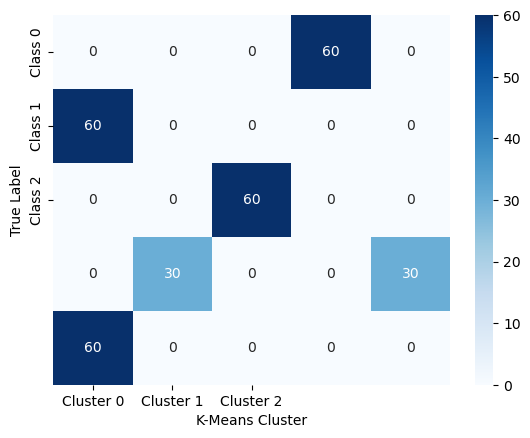

In [11]:
df_compare = pd.DataFrame({'True_Label': y, 'Predicted_Cluster': y_pred})
print(pd.crosstab(df_compare['True_Label'], df_compare['Predicted_Cluster']))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('K-Means Cluster')
plt.ylabel('True Label')
plt.show()

In [12]:
y_pred

array([3, 0, 3, 0, 3, 4, 0, 2, 1, 0, 0, 3, 0, 3, 0, 3, 0, 0, 0, 3, 3, 0,
       3, 0, 0, 3, 2, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 0, 4, 0, 3, 0, 2, 1,
       0, 1, 3, 2, 0, 2, 4, 0, 2, 1, 3, 1, 0, 3, 4, 2, 3, 4, 0, 0, 2, 0,
       2, 2, 2, 2, 0, 2, 4, 0, 4, 3, 4, 1, 0, 3, 2, 3, 3, 0, 3, 2, 4, 0,
       0, 0, 0, 0, 3, 0, 3, 3, 0, 1, 0, 0, 4, 4, 0, 2, 3, 3, 3, 0, 3, 0,
       4, 0, 0, 0, 3, 3, 3, 2, 4, 1, 4, 2, 1, 1, 3, 2, 0, 0, 4, 3, 0, 1,
       0, 3, 3, 3, 3, 0, 2, 0, 3, 4, 3, 0, 0, 3, 0, 2, 0, 2, 0, 2, 2, 0,
       3, 0, 2, 4, 3, 0, 1, 1, 0, 0, 3, 1, 0, 0, 0, 0, 2, 3, 0, 0, 3, 0,
       4, 0, 2, 2, 4, 1, 0, 2, 2, 0, 3, 1, 2, 0, 0, 2, 3, 2, 2, 1, 4, 2,
       0, 0, 1, 2, 0, 0, 1, 3, 3, 2, 2, 3, 2, 1, 0, 2, 3, 0, 1, 1, 2, 0,
       1, 4, 0, 4, 0, 0, 1, 0, 4, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 3, 4, 0,
       2, 0, 2, 1, 0, 0, 2, 2, 0, 0, 4, 2, 4, 0, 2, 0, 2, 0, 2, 3, 0, 0,
       0, 3, 0, 0, 2, 0, 1, 2, 2, 3, 3, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 2,
       2, 2, 0, 0, 4, 0, 2, 4, 3, 4, 2, 3, 0, 3], d

In [13]:
y_pred is kmeans.labels_

True

In [14]:
kmeans.cluster_centers_

array([[ 3.26972454,  3.11413579],
       [-8.05313434,  6.76835691],
       [-6.68626728, -6.96943511],
       [-2.64588966,  8.93756574],
       [-9.58882438,  7.7981948 ]])

In [15]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0,
2]])
kmeans = KMeans(n_clusters=5, init=good_init, random_state=42)
kmeans.fit(X)

KMeans(init=array([[-3,  3],
       [-3,  2],
       [-3,  1],
       [-1,  2],
       [ 0,  2]]),
       n_clusters=5, random_state=42)

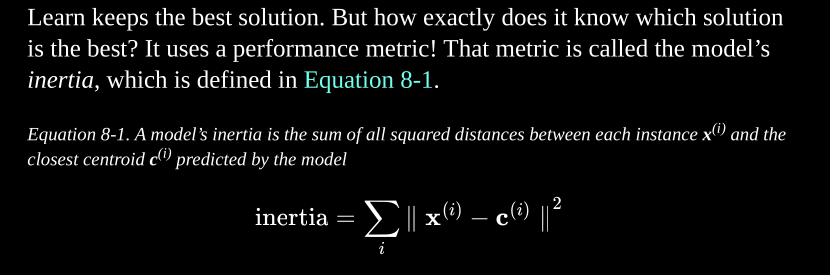

In [16]:
kmeans.inertia_

2055.6942574084624

In [19]:
kmeans.score(X)

-2055.694257408463

In [20]:
from sklearn.cluster import MiniBatchKMeans
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, random_state=42)

In [21]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.5872408916001899

# **Using Clustering for Image Segmentation**

In [ ]:
import PIL
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
filepath = r'/home/noneo/Codes/DeepLearning/DL Datasets/cats_and_dogs_filtered/cats_and_dogs_filtered/validation/dogs/dog.2000.jpg'
image = np.asarray(PIL.Image.open(filepath))
image.shape

(339, 200, 3)

K = 2, Silhouette Score = 0.4966
K = 3, Silhouette Score = 0.4971
K = 4, Silhouette Score = 0.4613
K = 5, Silhouette Score = 0.4345
K = 6, Silhouette Score = 0.4040
K = 7, Silhouette Score = 0.4332
K = 8, Silhouette Score = 0.4397
K = 9, Silhouette Score = 0.4255
K = 10, Silhouette Score = 0.4286


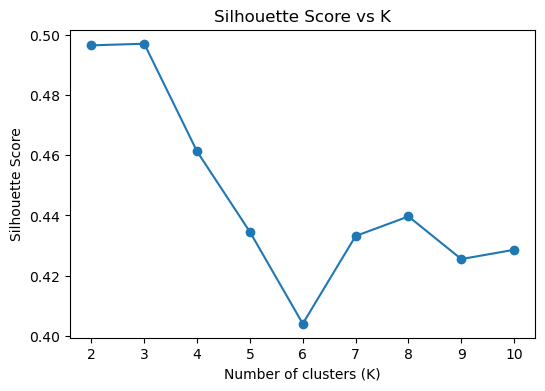

Best K = 3


In [25]:


X = image.reshape(-1, 3)

sil_scores = []
K_range = range(2, 11)  # start from 2 (silhouette can't work with 1 cluster)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

# Plot results
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Best K
best_k = K_range[np.argmax(sil_scores)]
print("Best K =", best_k)

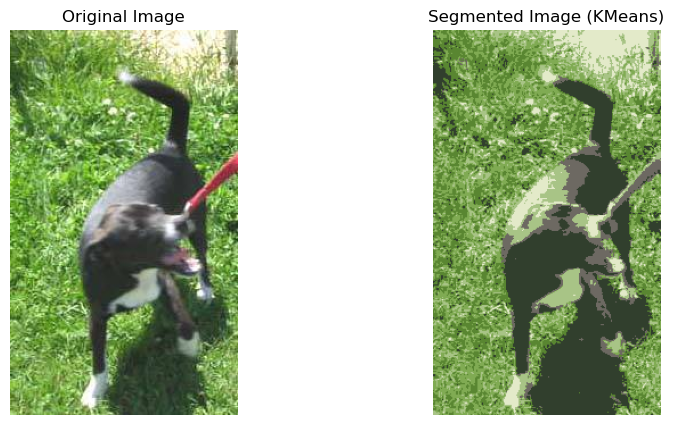

In [32]:
kmeans = KMeans(n_clusters=6, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

segmented_img = segmented_img.astype(np.uint8)

# show image
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmented Image (KMeans)")
plt.imshow(segmented_img)
plt.axis("off")

plt.show()

# **Using Clustering for Semi-Supervised Learning**

In [33]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [34]:
from sklearn.linear_model import LogisticRegression
n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [35]:
log_reg.score(X_test, y_test)

0.7581863979848866

# **K means Semi supervised learning**

# Understanding These Three Lines of K-Means Code

```python
X_digits_dist = kmeans.fit_transform(X_train)

representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]
```

This is the heart of the algorithm. Let's understand it by pretending we are the computer. Instead of using the real dataset (1,400 images and 50 clusters), we'll use a small example with **8 images** and **2 clusters**.

---

## Step 0: Before These Lines

Suppose our dataset contains these handwritten digit images:

| Image Index | Actual Digit |
| ----------- | ------------ |
| 0           | 8            |
| 1           | 1            |
| 2           | 0            |
| 3           | 8            |
| 4           | 3            |
| 5           | 1            |
| 6           | 9            |
| 7           | 0            |

Remember:

**K-Means does not know these labels.** It only sees the pixel values of the images.

---

# Line 1

```python
X_digits_dist = kmeans.fit_transform(X_train)
```

This line performs **two operations**.

## Operation 1: Fit the K-Means model

```python
kmeans.fit(X_train)
```

K-Means examines all the images and groups them into clusters.

For our small example (2 clusters), suppose it creates:

```
Cluster 0
---------
Image 0
Image 3
Image 6

Cluster 1
---------
Image 1
Image 2
Image 4
Image 5
Image 7
```

For each cluster, K-Means computes a **centroid**, which is simply the mathematical center (average) of all the images in that cluster.

Think of the centroid as the **average image** of the cluster.

---

## Operation 2: Measure distances

After finding the centroids, K-Means calculates the distance from every image to every centroid.

The resulting distance table might look like this:

| Image | Distance to Cluster 0 | Distance to Cluster 1 |
| ----- | --------------------: | --------------------: |
| 0     |                   0.5 |                   8.2 |
| 1     |                   7.8 |                   0.6 |
| 2     |                   8.5 |                   0.4 |
| 3     |                   0.3 |                   7.9 |
| 4     |                   6.5 |                   0.8 |
| 5     |                   7.2 |                   0.5 |
| 6     |                   0.7 |                   8.1 |
| 7     |                   8.0 |                   0.2 |

This table is stored in:

```python
X_digits_dist
```

Its shape is:

```
(Number of images, Number of clusters)

(8, 2)
```

For the real dataset:

```
(1400, 50)
```

Each row represents one image.

Each column represents one cluster.

Each value is the distance between that image and that cluster's centroid.

---

# Line 2

```python
representative_digit_idx = X_digits_dist.argmin(axis=0)
```

This line finds the representative image for every cluster.

## What does `argmin()` mean?

Suppose we have:

```python
numbers = [5, 8, 2, 9]
```

Then:

```python
numbers.min()
```

returns:

```
2
```

because 2 is the smallest value.

But:

```python
numbers.argmin()
```

returns:

```
2
```

because the smallest value is located at **index 2**.

---

## Apply this idea to the distance table

Distance table:

| Image | Dist to C0 | Dist to C1 |
| ----- | ---------: | ---------: |
| 0     |        0.5 |        8.2 |
| 1     |        7.8 |        0.6 |
| 2     |        8.5 |        0.4 |
| 3     |        0.3 |        7.9 |
| 4     |        6.5 |        0.8 |
| 5     |        7.2 |        0.5 |
| 6     |        0.7 |        8.1 |
| 7     |        8.0 |        0.2 |

Using:

```python
argmin(axis=0)
```

means:

**Look down each column separately.**

### Cluster 0 column

Distances:

```
0.5
7.8
8.5
0.3
6.5
7.2
0.7
8.0
```

Smallest distance:

```
0.3
```

This belongs to **Image 3**.

---

### Cluster 1 column

Distances:

```
8.2
0.6
0.4
7.9
0.8
0.5
8.1
0.2
```

Smallest distance:

```
0.2
```

This belongs to **Image 7**.

Therefore:

```python
representative_digit_idx
```

becomes:

```python
[3, 7]
```

For the real dataset, this array contains **50 indices**, one for each cluster.

Example:

```python
[84, 231, 902, 15, 661, ..., 1120]
```

Each number is the index of the image closest to a cluster centroid.

---

# Line 3

```python
X_representative_digits = X_train[representative_digit_idx]
```

Now we use those indices to retrieve the actual images.

Suppose:

```python
representative_digit_idx = [3, 7]
```

Then:

```python
X_train[representative_digit_idx]
```

means:

```
Select Image 3
Select Image 7
```

The resulting variable:

```python
X_representative_digits
```

contains only these representative images.

Instead of having:

```
1400 images
```

we now have:

```
50 representative images
```

One representative image for each cluster.

---

# Complete Flow

```
1400 Images
      │
      ▼
Apply K-Means
      │
      ▼
Create 50 Clusters
      │
      ▼
Compute 50 Centroids
      │
      ▼
Find the Image Closest to Each Centroid
      │
      ▼
Obtain 50 Representative Images
      │
      ▼
Human Labels Only These 50 Images
      │
      ▼
Train Logistic Regression
```

---

# Final Important Concept

A **centroid is not a real image**.

It is only the mathematical average of all the images inside a cluster.

Since we cannot label an "average image," we instead find the **real image that is closest to the centroid**.

That image becomes the **representative image** for that cluster.

---

## Key Concepts to Remember

* **Cluster** = A group of similar images.
* **Centroid** = The mathematical center (average) of a cluster.
* **Representative Image** = The real image closest to the centroid.
* **Representative Index** = The position of that representative image in `X_train`.

Once you clearly understand the difference between these four concepts, the entire semi-supervised learning algorithm becomes much easier to follow.


In [ ]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)

X_digits_dist = kmeans.fit_transform(X_train)

representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]

In [68]:
X_digits_dist.shape

(1400, 50)

In [57]:
representative_digit_idx

array([ 612, 1039,  326,  347,  468,  698, 1003, 1244,  959,  943,  723,
       1370,  128,  885,  708,  924, 1168,  438,  765,  517,  410, 1005,
        139,  299, 1312,  310, 1159,  210,  579,  469,   65,  877, 1148,
       1188, 1327,  987, 1185, 1291,  115,  886, 1309,  175,  251,  983,
        816,  384,  652,  162,  146,  640])

In [58]:
X_representative_digits

array([[ 0.,  0.,  0., ..., 15., 12.,  0.],
       [ 0.,  0.,  2., ...,  5.,  0.,  0.],
       [ 0.,  0.,  1., ...,  3.,  0.,  0.],
       ...,
       [ 0.,  5., 16., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 14.,  6.,  0.],
       [ 0.,  0.,  3., ...,  0.,  0.,  0.]])

In [61]:
y_representative_digits = y_train[representative_digit_idx]
y_representative_digits

array([8, 0, 1, 3, 6, 7, 5, 4, 2, 8, 2, 3, 9, 5, 3, 9, 1, 7, 9, 1, 4, 6,
       9, 7, 5, 2, 2, 1, 3, 3, 6, 0, 4, 9, 8, 1, 8, 4, 2, 4, 2, 3, 9, 7,
       8, 9, 6, 5, 6, 4])

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8312342569269522

In [63]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [64]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8664987405541562

In [65]:
percentile_closest = 50
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1
    
partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [66]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8841309823677582

In [67]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

0.9887798036465638

# **Density-Based Spatial Clustering Of Applications With Noise ->(DBSCAN)**

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [2]:
X

array([[-0.02137124,  0.40618608],
       [ 0.97670045, -0.45832306],
       [ 0.90405882, -0.37651952],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

In [4]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [3]:
dbscan.labels_

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5,  2,  3,  0,  2,  2,  2,  4,
        2,  2,  4,  0,  5,  1,  0,  5,  5,  3,  2,  2,  2,  4,  5,  0,  6,
        1, -1,  0,  0,  2,  3, -1,  3,  4, -1,  4,  4,  2,  0,  6,  2,  0,
        2,  4,  0,  3,  3,  0,  3,  5,  2, -1,  3,  0,  5,  0,  0,  0,  2,
        3,  0,  3,  6,  0,  2,  4,  4,  0,  3,  0,  4,  0,  3, -1,  3,  4,
        0, -1,  2,  2,  4,  1,  6,  0,  5,  2,  6,  2,  3,  3, -1,  2, -1,
        2,  4,  0,  0,  0,  2,  5,  2,  0,  2, -1,  2,  3,  1,  5,  2,  0,
        4,  2,  1,  2,  4,  4,  0,  0,  6,  2,  2,  0,  2, -1,  2,  0,  3,
        3,  5, -1,  3,  3,  5,  2,  4,  2,  2,  2,  4,  2,  4,  0, -1,  2,
        1,  2,  6,  4,  2,  3,  2, -1,  2,  0,  0,  2,  0,  4,  0,  4,  4,
        1,  6,  3,  2,  6,  1,  4,  4,  2,  0,  6,  0,  1,  0,  2,  5,  1,
        1,  2,  2,  2,  2,  0,  5,  5,  1,  4,  5,  0,  3,  3,  0,  0,  0,
        2,  0,  5,  2, -1,  2,  3,  5,  2,  2,  0,  4,  0,  4,  2,  2,  4,
        2,  2,  3,  2,  3

In [5]:
dbscan.core_sample_indices_

array([  0,   4,   5,   6,   7,   8,  10,  11,  12,  13,  14,  16,  17,
        18,  19,  20,  21,  22,  23,  24,  25,  26,  28,  29,  30,  31,
        32,  33,  34,  36,  38,  39,  41,  42,  44,  45,  47,  49,  50,
        51,  52,  53,  54,  55,  56,  58,  59,  61,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  83,  84,  85,  87,  88,  89,  90,  91,  93,  94,  96,
        97,  98, 102, 103, 104, 105, 106, 107, 108, 109, 110, 113, 114,
       115, 116, 117, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 135, 136, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149,
       150, 152, 153, 154, 155, 156, 157, 158, 159, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 172, 173, 174, 175, 176, 177, 178,
       179, 181, 182, 183, 185, 186, 187, 188, 189, 191, 193, 194, 195,
       196, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 209, 210,
       211, 212, 213, 214, 215, 216, 217, 218, 219, 221, 222, 22

In [6]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [9]:
import numpy as np
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([6, 0, 3, 2])

In [10]:
knn.predict_proba(X_new)

array([[0.24, 0.  , 0.  , 0.  , 0.  , 0.  , 0.76],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.3 , 0.7 , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  ]])

In [11]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  3, -1])

### **Comparison Table**

| Algorithm            | Need K?                                    | Handles Arbitrary Shapes? | Good for Large Data? | Main Idea                                             |
| -------------------- | ------------------------------------------ | ------------------------- | -------------------- | ----------------------------------------------------- |
| Agglomerative        | No (you choose where to cut the tree)      | ✅ Yes                     | ❌ Moderate           | Merge nearest clusters into a hierarchy               |
| BIRCH                | Usually yes (for final clustering stage)   | Limited                   | ✅ Excellent          | Compress data into a tree of summaries                |
| Mean Shift           | ❌ No                                       | ✅ Yes                     | ❌ No                 | Move windows toward density peaks                     |
| Affinity Propagation | ❌ No                                       | Moderate                  | ❌ No                 | Points vote for exemplar representatives              |
| Spectral Clustering  | Usually yes (uses K-Means after embedding) | ✅ Excellent               | ❌ No                 | Transform data using graph similarities, then cluster |

When Should You Use Each?

Agglomerative Clustering: When you want to explore hierarchical relationships or don't know the best number of clusters in advance.

BIRCH: When your dataset is extremely large and memory efficiency is important.
Mean Shift: When you want the algorithm to automatically discover dense regions without specifying the number of clusters.

Affinity Propagation: When you want representative data points (exemplars) and the algorithm to determine the number of clusters automatically.

Spectral Clustering: When clusters have complex, non-convex shapes (such as concentric circles or connected graph communities) that methods like K-Means struggle to separate.

# **Gaussian Mixtures**

In [14]:

img = cv2.imread(r'/home/noneo/Codes/DeepLearning/DL Datasets/cats_and_dogs_filtered/cats_and_dogs_filtered/validation/dogs/dog.2000.jpg')

img2 = img.reshape((-1, 3))

from sklearn.mixture import GaussianMixture as GMM

gmm_model = GMM(n_components=5, covariance_type='tied').fit(img2)

gmm_labels = gmm_model.predict(img2)

original_shape = img.shape

segmented = gmm_labels.reshape(original_shape[0], original_shape[1])

cv2.imwrite("segmented_plant.jpg", segmented)

True

K = 4, Silhouette Score = 0.6777

Best K = 4, Best Score = 0.6777


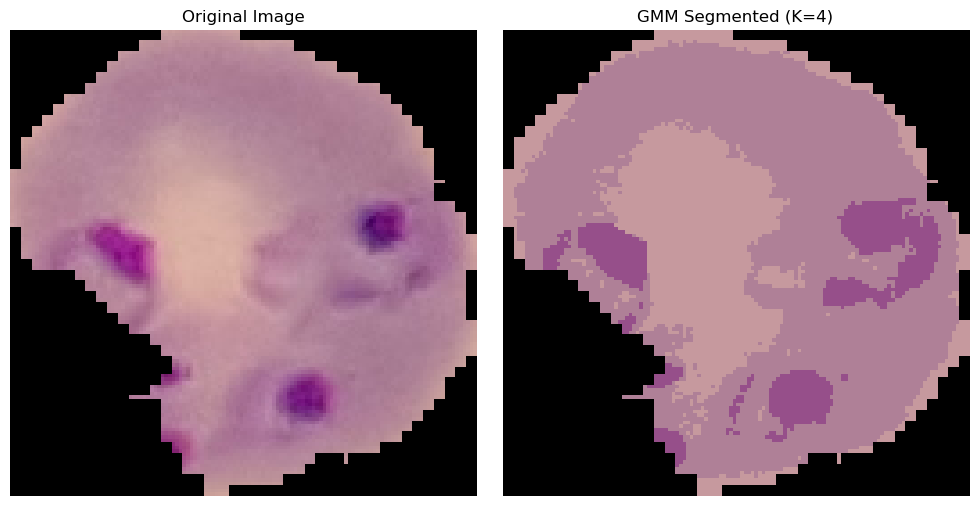

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# ==========================
# Read Image
# ==========================
image = cv2.imread(
    r"/home/noneo/Codes/DeepLearning/DL Datasets/Malaria_dataset_images/Parasitized/C39P4thinF_original_IMG_20150622_114804_cell_30.png"
)

# Check image
if image is None:
    raise ValueError("Image not found. Check the path.")

# Convert BGR → RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Save original shape
original_shape = image.shape

# Flatten image
X = image.reshape((-1, 3)).astype(np.float64)

# ==========================
# Silhouette Score for best K
# ==========================
sil_scores = []
K_range = range(4, 5)

best_k = None
best_score = -1
best_model = None
best_labels = None

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        init_params='k-means++',
        covariance_type='spherical',
        random_state=42
    )

    labels = gmm.fit_predict(X)

    score = silhouette_score(X, labels)
    sil_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k
        best_model = gmm
        best_labels = labels

print(f"\nBest K = {best_k}, Best Score = {best_score:.4f}")

# ==========================
# Final Segmentation using best model
# ==========================
segmented_img = best_model.means_[best_labels]
segmented_img = segmented_img.reshape(original_shape)

segmented_img = np.clip(segmented_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"GMM Segmented (K={best_k})")
plt.imshow(segmented_img)
plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=4,covariance_type='spherical',init_params='k-means++',
                              random_state=42)

bgm.fit_predict(X)
bgm.weights_.round(2)


array([0.41, 0.33, 0.19, 0.07])

# **AIC and BIC** 

Akaike Information Critersion and Basyesain Information Critions 

K=2 | BIC=65240.87 | AIC=65093.90
K=3 | BIC=46400.85 | AIC=46176.53
K=4 | BIC=43616.09 | AIC=43314.42
K=5 | BIC=39951.79 | AIC=39572.77
K=6 | BIC=38413.06 | AIC=37956.69
K=7 | BIC=36586.82 | AIC=36053.10
K=8 | BIC=37613.60 | AIC=37002.53
K=9 | BIC=37587.53 | AIC=36899.11
K=10 | BIC=37552.75 | AIC=36786.98

Best K according to BIC: 7


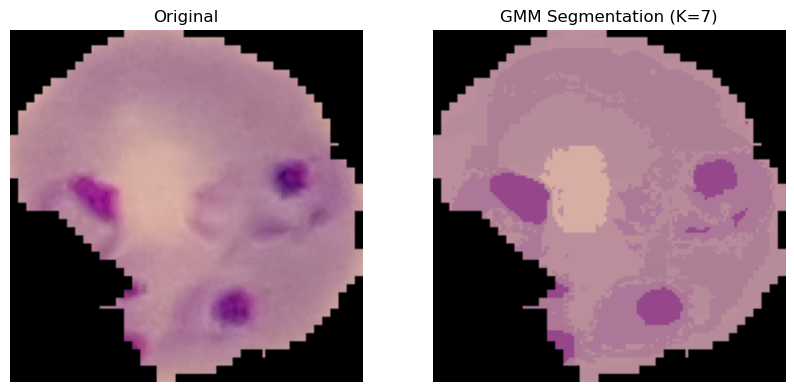

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Read image
image = cv2.imread(r"/home/noneo/Codes/DeepLearning/DL Datasets/Malaria_dataset_images/Parasitized/C39P4thinF_original_IMG_20150622_114804_cell_30.png")

if image is None:
    raise ValueError("Image not found")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

X = image.reshape((-1, 3)).astype(np.float64)

bic_scores = []
aic_scores = []
K_range = range(2, 11)

best_k = None
best_model = None
best_bic = np.inf

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X)

    bic = gmm.bic(X)
    aic = gmm.aic(X)

    bic_scores.append(bic)
    aic_scores.append(aic)

    print(f"K={k} | BIC={bic:.2f} | AIC={aic:.2f}")

    if bic < best_bic:
        best_bic = bic
        best_k = k
        best_model = gmm

print("\nBest K according to BIC:", best_k)

# Segment image using best model
labels = best_model.predict(X)
segmented = best_model.means_[labels]
segmented = segmented.reshape(image.shape)
segmented = np.clip(segmented, 0, 255).astype(np.uint8)

# Show result
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"GMM Segmentation (K={best_k})")
plt.imshow(segmented)
plt.axis("off")

plt.show()